<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import openpyxl



In [2]:
#Importation de la librairie plotly express
import plotly.express as px 

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

affichage_collones = pd.set_option('display.max_columns', None)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

d:\Cours DATA\Cour OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\Cours DATA\Cour OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\Cours DATA\Cour OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
doublons = df_erp.duplicated()
if df_erp.duplicated().any():
    print(doublons)

In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp["stock_status"].unique()
#les valeur de la colonne stock_status sont liées a la colonne stock_quantity si celle ci est egale a 0 alors outofstock

<StringArray>
['instock', 'outofstock']
Length: 2, dtype: str

In [10]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = np.where(df_erp["stock_quantity"] <= 0, "outofstock", "instock")
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
difference = df_erp["stock_status"] == df_erp["stock_status_2"]
difference

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [12]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
count_difference = difference.sum()
print(f'il y a {825-count_difference} difference entre les deux colonnes')

il y a 2 difference entre les deux colonnes


In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
ecart = (df_erp["stock_status"] != df_erp["stock_status_2"])
df_erp["ecart"] = ecart

df_erp[df_erp["ecart"] == True]



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
4,4039,1,46.0,3,outofstock,23.77,instock,True
398,4885,1,18.7,0,instock,9.66,outofstock,True


In [14]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp["ecart"] == True, "stock_status"] = df_erp["stock_status_2"]
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
ecart = (df_erp["stock_status"] != df_erp["stock_status_2"])
df_erp["ecart"] = ecart

df_erp[df_erp["ecart"] == True]



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
prix_incoherent = (df_erp["price"] <0 | df_erp["price"].isna())
df_prix_erreur = df_erp[prix_incoherent]
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_prix_erreur)) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
prix_mini = df_erp["price"].min()
print(f"le prix mini est {prix_mini}")
#Afficher le prix maximum de la colonne "price"
prix_maxi = df_erp["price"].max()
print(f"le prix maxi est {prix_maxi}")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_inf_zero = (df_erp["price"] < 0)
df_prix_inf_zero = df_erp[prix_inf_zero]
display(df_prix_inf_zero)

Nombres d'articles avec un prix non renseigné:      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  ecart  
151           10.33     outofstock  False  
469            4.34     outofstock  False  
739            4.61        instock  False  
le prix mini est -20.0
le prix maxi est 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
151,4233,0,-20.0,0,outofstock,10.33,outofstock,False
469,5017,0,-8.0,0,outofstock,4.34,outofstock,False
739,6594,0,-9.1,19,instock,4.61,instock,False


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
stock_incoherent = (df_erp["stock_quantity"] <0 | df_erp["stock_quantity"].isna())
df_stock_erreur = df_erp[stock_incoherent]
display(df_stock_erreur)
#Afficher la quantité minimum de la colonne "stock_quantity"
stock_mini = df_erp["stock_quantity"].min()
print(f"le stock mùini est {stock_mini}")
#Afficher la quantité maximum de la colonne "stock_quantity"
stock_maxi = df_erp["stock_quantity"].max()
print(f"le le stock maxi est {stock_maxi}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
stock_inf_zero = (df_erp["stock_quantity"] < 0)
df_stock_inf_zero = df_erp[stock_inf_zero]
display(df_stock_inf_zero)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
449,4973,0,10.0,-10,outofstock,4.96,outofstock,False
573,5700,1,44.5,-1,outofstock,22.30,outofstock,False


le prix stock est -10
le le stock maxi est 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
449,4973,0,10.0,-10,outofstock,4.96,outofstock,False
573,5700,1,44.5,-1,outofstock,22.30,outofstock,False


In [ ]:
stock_sans_vente = (df_erp["stock_quantity"]>0) & (df_erp["onsale_web"]== 0)
df_stock_sans_vente = df_erp[stock_sans_vente]
display(df_stock_sans_vente)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
123,4200,0,5.8,33,instock,3.12,instock,False
234,4565,0,30.5,3,instock,15.92,instock,False
238,4577,0,49.0,1,instock,24.05,instock,False
239,4578,0,40.0,3,instock,20.05,instock,False
318,4692,0,12.0,48,instock,6.39,instock,False
...,...,...,...,...,...,...,...,...
818,7200,0,31.0,6,instock,15.54,instock,False
819,7201,0,31.0,18,instock,16.02,instock,False
820,7203,0,45.0,30,instock,23.48,instock,False
821,7204,0,45.0,9,instock,24.18,instock,False


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
onsale_web_incoherent = df_erp["onsale_web"].value_counts(dropna=False)
display(onsale_web_incoherent)
print("la colone onsale_web contient les données qui donne l'indication de si le bien est vendu ou non sur le web: \n la valeur 1 = oui la valeur 0 = non") 



onsale_web
1    716
0    109
Name: count, dtype: int64

la colone onsale_web contient les données qui donne l'indication de si le bien est vendu ou non sur le web: 
 la valeur 1 = oui la valeur 0 = non


In [ ]:
#Quelles sont les colonnes à conserver selon vous?
#toutes saut ecart et stock status_2
display(df_erp)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,ecart
0,3847,1,24.2,16,instock,12.88,instock,False
1,3849,1,34.3,10,instock,17.54,instock,False
2,3850,1,20.8,0,outofstock,10.64,outofstock,False
3,4032,1,14.1,26,instock,6.92,instock,False
4,4039,1,46.0,3,instock,23.77,instock,False
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock,False
821,7204,0,45.0,9,instock,24.18,instock,False
822,7247,1,54.8,6,instock,27.18,instock,False
823,7329,0,26.5,14,instock,13.42,instock,False


In [ ]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
colonne_sup = ["stock_status_2", "ecart"]
df_erp.drop(columns=colonne_sup, inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
prix_achat = (df_erp["purchase_price"].isna()|df_erp["purchase_price"]<=0)
df_prix_nan = df_erp[prix_achat]
display(df_prix_nan)
print("Il n'y a aucun prix d'achat nul ou négatif")
#Afficher le prix minimum de la colonne "purchase_price"
prix_achat_min = df_erp["purchase_price"].min()
print(f"le prix d'achat mini est {prix_achat_min}€")
#Afficher le prix maximum de la colonne "purchase_price"
prix_achat_max = df_erp["purchase_price"].max()
print(f"le prix d'achat maxi est {prix_achat_max}€")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


Il n'y a aucun prix d'achat nul ou négatif
le prix d'achat mini est 2.74€
le prix d'achat maxi est 137.81€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [ ]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Nombre de caractéristiques
df_web.info()

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)
<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float

In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()


<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [ ]:
#colonne a conserver
colonnes_conservees = []
for c in df_web.columns:
    nb_unique = df_web[c].nunique()
    if nb_unique > 1:
        colonnes_conservees.append(c)
    print(f"{c} contient {nb_unique} valeurs uniques.")
colonnes_conservees

sku contient 714 valeurs uniques.
virtual contient 1 valeurs uniques.
downloadable contient 1 valeurs uniques.
rating_count contient 1 valeurs uniques.
average_rating contient 1 valeurs uniques.
total_sales contient 29 valeurs uniques.
tax_status contient 1 valeurs uniques.
tax_class contient 0 valeurs uniques.
post_author contient 2 valeurs uniques.
post_date contient 716 valeurs uniques.
post_date_gmt contient 716 valeurs uniques.
post_content contient 0 valeurs uniques.
product_type contient 7 valeurs uniques.
post_title contient 713 valeurs uniques.
post_excerpt contient 679 valeurs uniques.
post_status contient 1 valeurs uniques.
comment_status contient 1 valeurs uniques.
ping_status contient 1 valeurs uniques.
post_password contient 0 valeurs uniques.
post_name contient 716 valeurs uniques.
post_modified contient 589 valeurs uniques.
post_modified_gmt contient 589 valeurs uniques.
post_content_filtered contient 0 valeurs uniques.
post_parent contient 1 valeurs uniques.
guid conti

['sku',
 'total_sales',
 'post_author',
 'post_date',
 'post_date_gmt',
 'product_type',
 'post_title',
 'post_excerpt',
 'post_name',
 'post_modified',
 'post_modified_gmt',
 'guid',
 'post_type']

In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?
#les colonnes a conserver sont celle qui ne contiennent pas 1 ou 0 valeurs unique 
#j'ai donc choisis de faire une liste colonnes conservées dans le bloc ci dessus 
print(f"la liste des colonnes à conservé est {colonnes_conservees}")


la liste des colonnes à conservé est ['sku', 'total_sales', 'post_author', 'post_date', 'post_date_gmt', 'product_type', 'post_title', 'post_excerpt', 'post_name', 'post_modified', 'post_modified_gmt', 'guid', 'post_type']


In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[colonnes_conservees]
df_web.head()

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
0,11862,3.0,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1,16057,5.0,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
2,14692,5.0,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,https://www.bottle-neck.fr/?post_type=product&...,product
3,16295,14.0,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
4,15328,2.0,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,https://www.bottle-neck.fr/?post_type=product&...,product


In [ ]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web['sku'].str.len().unique()



array([nan,  7., 19.])

In [ ]:
print("les colonnes contenant la valeur nan ne sont pas cohérentes")

les colonnes contenant la valeur nan ne sont pas cohérentes


In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
#il y a t'il des sku non numeric
is_num = df_web['sku'].str.isnumeric()

erreurs_format = df_web[(is_num == False) & (df_web['sku'].notna())]

display(erreurs_format)

print("Malgrés un format non numerique ")

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
272,13127-1,4.0,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/?post_type=product&...,product
842,bon-cadeau-25-euros,7.0,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1117,13127-1,4.0,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1387,bon-cadeau-25-euros,7.0,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,https://www.bottle-neck.fr/?post_type=product&...,product


Malgrés un format non numerique 


In [ ]:
#Identifier les lignes sans code article
sku_nan = (df_web['sku'].isna())
sku_nan_true = df_web[sku_nan]
display(sku_nan_true)

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
8,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
20,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
30,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
37,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
41,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
1429,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
1432,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN
1445,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN


In [ ]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
#suprimer les ligne qui ne seulement du Nan ou du nat
df_web_sans_nan = df_web.dropna(subset=['sku'])
display(df_web_sans_nan)

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
0,11862,3.0,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1,16057,5.0,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
2,14692,5.0,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,https://www.bottle-neck.fr/?post_type=product&...,product
3,16295,14.0,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
4,15328,2.0,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,https://www.bottle-neck.fr/?post_type=product&...,product
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,5.0,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,https://www.bottle-neck.fr/?post_type=product&...,product
1509,15662,15.0,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,https://www.bottle-neck.fr/?post_type=product&...,product
1510,15329,3.0,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1511,14827,7.0,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment


In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web_sans_nan['sku'].value_counts()
#comme nous pouvonns le constater tous les sku sont doublés aprés annalyse il y pour chaque SKU une ligne product et une ligne attachement 

sku
11862    2
16057    2
14692    2
16295    2
15328    2
        ..
16043    2
15845    2
15951    2
13074    2
14569    2
Name: count, Length: 714, dtype: int64

In [ ]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
#fait precedement 
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_sans_nan.info()
#3 - Que constatez-vous?
print("la colone post_type comporte deux valeur une en product et une en attachement qui sont rattacher au même SKU \n on peut en deduire que se sont des doublons car le SKU est idendique ")

<class 'pandas.DataFrame'>
Index: 1428 entries, 0 to 1512
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                1428 non-null   object        
 1   total_sales        1428 non-null   float64       
 2   post_author        1428 non-null   float64       
 3   post_date          1428 non-null   datetime64[us]
 4   post_date_gmt      1428 non-null   datetime64[us]
 5   product_type       1427 non-null   str           
 6   post_title         1428 non-null   str           
 7   post_excerpt       714 non-null    str           
 8   post_name          1428 non-null   str           
 9   post_modified      1428 non-null   datetime64[us]
 10  post_modified_gmt  1428 non-null   datetime64[us]
 11  guid               1428 non-null   str           
 12  post_type          1428 non-null   str           
dtypes: datetime64[us](4), float64(2), object(1), str(6)
memory usage: 156.2+ KB
la 

In [ ]:
#les doublons des lignes sur la colonne post_type risque de perturber l'analyse je filtre donc la colonne post_type sur la valeur product

df_web_sans_nan = df_web_sans_nan.loc[df_web_sans_nan["post_type"]== "product",:]
print(f"le tableau comprend {len(df_web_sans_nan)} lignes apres la surppression des doublons")

le tableau comprend 714 lignes apres la surppression des doublons


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre de caractéristiques
df_liaison.info()



Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)
<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()
print("une première information est visible il y a des lignes sans id_web")

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB
une première information est visible il y a des lignes sans id_web


In [ ]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
#nombre de valeur unique 
unique_product_id = df_liaison['product_id'].nunique()
print(f"il ya {unique_product_id} valeurs unique sur 825 valeurs dans la table")
#nombre de nan
nan_product_id = df_liaison['product_id'].isna().sum()
print(f"il ya {nan_product_id} valeur NAN dans la table")

il ya 825 valeurs unique sur 825 valeurs dans la table
il ya 0 valeur NAN dans la table


In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
unique_web_id = df_liaison['id_web'].nunique()
print(f"il ya {unique_web_id} valeur unique sur 734 valeurs dans la table" )
#nombre de nan 
nan_web_id = df_liaison["id_web"].isna().sum()
print(f"il ya {nan_web_id} valeur NAN dans la table")

il ya 734 valeur unique sur 734 valeurs dans la table
il ya 91 valeur NAN dans la table


In [ ]:
#Avons-nous des articles sans correspondance?
df_liaison.loc[df_liaison['id_web'].isna() | df_liaison['product_id'].isna()]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(left=df_erp, right=df_liaison, on="product_id", how='left', indicator=True)
display(df_erp_liaison)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,both
821,7204,0,45.0,9,instock,24.18,NaN,both
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [ ]:
display(df_web_sans_nan)

,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
2,14692,5.0,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,https://www.bottle-neck.fr/?post_type=product&...,product
4,15328,2.0,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,https://www.bottle-neck.fr/?post_type=product&...,product
6,16515,10.0,2.0,2018-06-02 09:31:31,2018-06-02 07:31:31,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,"<div id=""wrapper"">\n<div id=""container-wrapper...",chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 10:11:12,2020-08-27 08:11:12,https://www.bottle-neck.fr/?post_type=product&...,product
11,16585,15.0,2.0,2018-02-16 14:03:16,2018-02-16 13:03:16,Vin,Xavier Frissant Touraine Sauvignon 2019,"Un joli sauvignon frais et minéral, avec d'int...",xavier-frissant-touraine-sauvignon-2019,2020-08-27 09:30:36,2020-08-27 07:30:36,https://www.bottle-neck.fr/?post_type=product&...,product
14,12869,7.0,2.0,2019-03-28 14:29:35,2019-03-28 13:29:35,Vin,Stéphane Tissot Arbois D.D. 2016,"Un Vin coloré et éclatant. Le nez est fruité, ...",stephane-tissot-arbois-dd-2016,2019-12-13 15:40:01,2019-12-13 14:40:01,https://www.bottle-neck.fr/?post_type=product&...,product
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,13074,4.0,2.0,2018-02-12 14:25:28,2018-02-12 13:25:28,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,"""L'Avenue"" est issue d’une parcelle de vieux g...",chateau-de-vaudieu-chateauneuf-du-pape-lavenue...,2019-12-09 10:40:03,2019-12-09 09:40:03,https://www.bottle-neck.fr/?post_type=product&...,product
1505,16322,0.0,2.0,2018-02-15 13:51:32,2018-02-15 12:51:32,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,Belle complexité aromatique alliant fruits rou...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,2020-08-26 16:05:03,2020-08-26 14:05:03,https://www.bottle-neck.fr/?post_type=product&...,product
1507,12365,10.0,2.0,2019-01-29 15:53:05,2019-01-29 14:53:05,Vin,Parés Baltà Penedès Electio 2013,Une cuvée produite avec une très vieille vigne...,pares-balta-penedes-electio-2013,2020-08-08 17:45:02,2020-08-08 15:45:02,https://www.bottle-neck.fr/?post_type=product&...,product
1508,16326,5.0,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,https://www.bottle-neck.fr/?post_type=product&...,product


In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
correspondance = df_erp_liaison["_merge"].value_counts()
print("l'indicateur _merge nous indique bien une correspondance total entre les deux tables ")
correspondance

l'indicateur _merge nous indique bien une correspondance total entre les deux tables 


_merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64

In [ ]:
#supression de la colonne _merge du fichier

df_erp_liaison.drop(columns="_merge", inplace=True)
df_erp_liaison.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionner les datasets df_merge et df_web
df_complet = pd.merge(left=df_erp_liaison, right=df_web_sans_nan, left_on='id_web', right_on='sku', how='inner', indicator=True)
display(df_complet)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,_merge
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,both
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,both
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,both
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product,both
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,1,8.4,28,instock,4.34,16135,16135,9.0,2.0,2020-04-25 13:22:38,2020-04-25 11:22:38,Vin,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,Belle robe jeune à dominante rubis soutenue. N...,mouthes-le-bihan-aime-chai-2015,2020-08-26 17:35:03,2020-08-26 15:35:03,https://www.bottle-neck.fr/?post_type=product&...,product,both
710,7023,1,27.5,23,instock,14.21,15891,15891,9.0,2.0,2020-05-02 14:53:40,2020-05-02 12:53:40,Vin,Camin Larredya Jurançon Sec La Virada 2018,L'exotisme du nez est complété par d'élégantes...,camin-larredya-jurancon-sec-la-virada-2018,2020-08-26 17:35:02,2020-08-26 15:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,both
711,7025,1,69.0,8,instock,34.22,15887,15887,5.0,2.0,2020-05-02 15:00:54,2020-05-02 13:00:54,Vin,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,"Pour cette cuvée, Jean-Paul Jamet recherche un...",jamet-cote-rotie-fructus-voluptas-2018,2020-08-14 18:15:03,2020-08-14 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,both
712,7247,1,54.8,6,instock,27.18,13127-1,13127-1,4.0,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/?post_type=product&...,product,both


In [ ]:
#Avons-nous des lignes sans correspondance?
print("l'indicateur _merge nous indique bien une correspondance total entre les deux tables ")
df_complet["_merge"].value_counts()

l'indicateur _merge nous indique bien une correspondance total entre les deux tables 


_merge
both          714
left_only       0
right_only      0
Name: count, dtype: int64

In [ ]:
#suppression de la colonne _merge car plus utile
df_complet.drop(columns="_merge", inplace=True)
df_complet.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

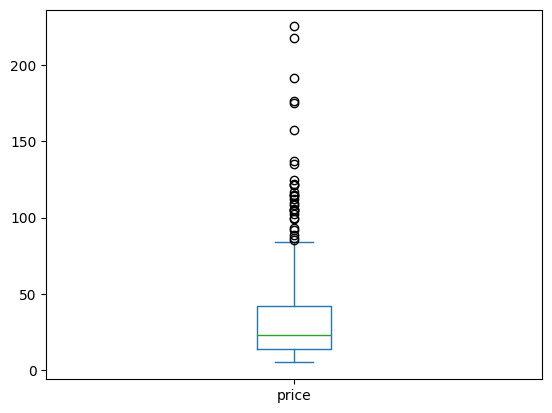

In [ ]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_complet['price'].plot(kind='box')

In [ ]:
print(df_complet.columns)

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price', 'id_web', 'sku', 'total_sales', 'post_author',
       'post_date', 'post_date_gmt', 'product_type', 'post_title',
       'post_excerpt', 'post_name', 'post_modified', 'post_modified_gmt',
       'guid', 'post_type'],
      dtype='str')


In [ ]:
#Autre méthode avec plotly express
fig = px.box(df_complet, x="price", title="Analyse des prix",color_discrete_sequence=['#004B3D'], labels={"price":"Prix en €"})
fig.show()

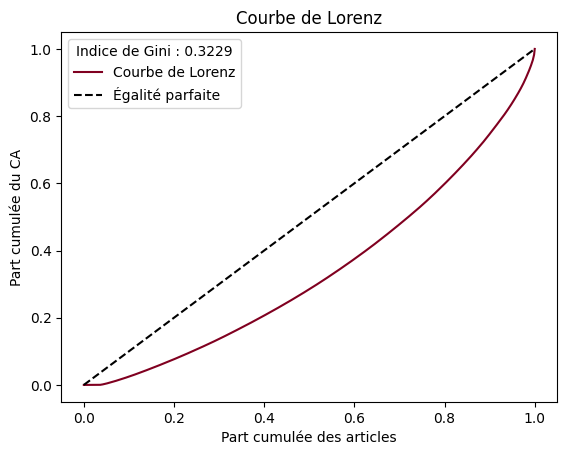

In [ ]:
# 1. On trie les données
data = df_complet['ca_article'].sort_values().values

# 2. On calcule la part cumulée des richesses (Y)
lorenz = np.cumsum(data) / data.sum()

# 3. On crée l'axe X (part cumulée de la population, de 0 à 1)
x = np.linspace(0, 1, len(lorenz))

# 4. On ajoute un point 0 au début pour que la courbe parte de l'origine
x = np.insert(x, 0, 0)
lorenz = np.insert(lorenz, 0, 0)

# Calcul de l'indice de Gini
gini = 1 - 2 * np.trapezoid(lorenz, x)

# Affichage
plt.plot(x, lorenz, color='#800020', label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], color='#004B3D', linestyle='--', label='Égalité parfaite')
plt.title("Courbe de Lorenz")
plt.xlabel("Part cumulée des articles")
plt.ylabel("Part cumulée du CA")
plt.legend(title=f"Indice de Gini : {gini:.4f}")
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [ ]:
#Calculer la moyenne du prix
prix_moyen = df_complet['price'].mean()
print(f"Le prix moyen des produit du site est de {prix_moyen:.2f}€")
#Calculer l'écart-type du prix
ecart_type = df_complet['price'].std()
print(f"l'ecart type du prix est de {ecart_type:.2f}")
#Calculer le Z-score
df_complet['z_score'] = (df_complet['price'] - prix_moyen) / ecart_type
display(df_complet)

Le prix moyen des produit du site est de 32.33€
l'ecart type du prix est de 27.60


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,z_score
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,-0.294738
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,0.071253
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,-0.417943
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product,-0.660729
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product,0.495222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,1,8.4,28,instock,4.34,16135,16135,9.0,2.0,2020-04-25 13:22:38,2020-04-25 11:22:38,Vin,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,Belle robe jeune à dominante rubis soutenue. N...,mouthes-le-bihan-aime-chai-2015,2020-08-26 17:35:03,2020-08-26 15:35:03,https://www.bottle-neck.fr/?post_type=product&...,product,-0.867278
710,7023,1,27.5,23,instock,14.21,15891,15891,9.0,2.0,2020-05-02 14:53:40,2020-05-02 12:53:40,Vin,Camin Larredya Jurançon Sec La Virada 2018,L'exotisme du nez est complété par d'élégantes...,camin-larredya-jurancon-sec-la-virada-2018,2020-08-26 17:35:02,2020-08-26 15:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,-0.175157
711,7025,1,69.0,8,instock,34.22,15887,15887,5.0,2.0,2020-05-02 15:00:54,2020-05-02 13:00:54,Vin,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,"Pour cette cuvée, Jean-Paul Jamet recherche un...",jamet-cote-rotie-fructus-voluptas-2018,2020-08-14 18:15:03,2020-08-14 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,1.328666
712,7247,1,54.8,6,instock,27.18,13127-1,13127-1,4.0,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/?post_type=product&...,product,0.814105


In [ ]:
#Quel est le seuil prix dont le z-score est supérieur à 3?

outliers = df_complet.loc[df_complet['z_score'] > 3]
outliers.info()

<class 'pandas.DataFrame'>
Index: 13 entries, 199 to 657
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         13 non-null     int64         
 1   onsale_web         13 non-null     int64         
 2   price              13 non-null     float64       
 3   stock_quantity     13 non-null     int64         
 4   stock_status       13 non-null     str           
 5   purchase_price     13 non-null     float64       
 6   id_web             13 non-null     object        
 7   sku                13 non-null     object        
 8   total_sales        13 non-null     float64       
 9   post_author        13 non-null     float64       
 10  post_date          13 non-null     datetime64[us]
 11  post_date_gmt      13 non-null     datetime64[us]
 12  product_type       13 non-null     str           
 13  post_title         13 non-null     str           
 14  post_excerpt       13 non

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_complet.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,post_author,post_date,post_date_gmt,post_modified,post_modified_gmt,z_score
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714,714,714,714,7.140000e+02
mean,5032.557423,0.998599,32.333683,23.443978,16.904006,8.054622,1.998599,2018-08-22 03:57:52.950980,2018-08-22 02:29:08.581232,2020-06-20 21:45:25.694677,2020-06-20 19:51:53.929972,-3.980632e-17
min,3847.000000,0.000000,5.200000,-1.000000,2.740000,0.000000,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,2018-02-20 15:19:23,2018-02-20 14:19:23,-9.832351e-01
25%,4280.250000,1.000000,14.062500,9.000000,7.240000,5.000000,2.000000,2018-02-27 20:01:12.500000,2018-02-27 19:01:12.500000,2020-06-18 18:32:35,2020-06-18 16:32:35,-6.620874e-01
50%,4796.000000,1.000000,23.450000,20.000000,12.305000,8.000000,2.000000,2018-04-19 14:52:10,2018-04-19 12:52:10,2020-08-04 09:30:06.500000,2020-08-04 07:30:06.500000,-3.219154e-01
75%,5710.500000,1.000000,42.075000,30.000000,22.030000,11.000000,2.000000,2019-01-31 14:35:47,2019-01-31 13:35:47,2020-08-25 10:32:32,2020-08-25 08:32:32,3.529932e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,36.000000,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,2020-08-27 18:55:03,2020-08-27 16:55:03,6.981591e+00
std,790.510878,0.037424,27.596332,22.220755,14.827384,4.161344,0.037424,NaN,NaN,NaN,NaN,1.000000e+00


In [ ]:
#Définir un seuil pour les articles "outliers" en prix
outliers_haut = 42.075 + (1.5 * ecart_type)
outliers_bas = 14.0625 - (1.5 * ecart_type)
print(f"le seuil de prix haut considiré en outlier est {outliers_haut:.2f}€ et le seuil de prix bas est {outliers_bas:.2f}€")

le seuil de prix haut considiré en outlier est 83.47€ et le seuil de prix bas est -27.33€


In [ ]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_sup = df_complet.loc[df_complet['price'] > outliers_haut].sort_values(by='price')
outliers_sup.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,z_score
506,5580,1,83.7,4,instock,41.08,13982,13982,2.0,2.0,2018-11-26 15:19:55,2018-11-26 14:19:55,Vin,Lucien Boillot Puligny-Montrachet 1er Cru Les ...,"<span style=""float: none; background-color: tr...",lucien-boillot-puligny-montrachet-1er-cru-les-...,2020-07-21 18:15:02,2020-07-21 16:15:02,https://www.bottle-neck.fr/?post_type=product&...,product,1.861346
205,4359,1,85.6,112,instock,51.93,13853,13853,7.0,2.0,2018-03-02 11:11:48,2018-03-02 10:11:48,Champagne,Champagne Larmandier-Bernier Grand Cru Les Che...,Belle maîtrise de ce millésime compliqué en Ch...,champagne-larmandier-bernier-grand-cru-vieille...,2019-12-23 09:30:11,2019-12-23 08:30:11,https://www.bottle-neck.fr/?post_type=product&...,product,1.930195
438,5026,1,86.8,101,instock,50.13,13913,13913,9.0,2.0,2018-07-18 10:46:30,2018-07-18 08:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,1.973680
65,4132,1,88.4,7,instock,44.30,11668,11668,5.0,2.0,2018-02-13 11:43:55,2018-02-13 10:43:55,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,Le nez dévoile déjà une belle intensité de fru...,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2020-02-20 09:55:02,2020-02-20 08:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,2.031658
502,5565,1,92.0,0,outofstock,46.11,19822,19822,1.0,2.0,2018-11-26 10:59:10,2018-11-26 09:59:10,Vin,Tempier Bandol Cabassaou 2017,"<div id=""wrapper"">\n<div id=""container-wrapper...",tempier-bandol-cabassaou-2017,2020-01-04 13:57:04,2020-01-04 12:57:04,https://www.bottle-neck.fr/?post_type=product&...,product,2.162110


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible?
outliers_sup[["price", 'product_type','post_title' ]].sort_values(by="price", ascending=False)



#nous remarquons que c'est des vin champagne ou cognac grand cru les prix me semble donc justifié

,price,product_type,post_title
199,225.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008
426,217.5,Vin,David Duband Charmes-Chambertin Grand Cru 2014
587,191.3,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...
218,176.0,Cognac,Cognac Frapin VIP XO
553,175.0,Vin,Camille Giroud Clos de Vougeot 2016
221,157.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...
381,137.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...
642,135.0,Champagne,Champagne Gosset Célébris Vintage 2007
511,124.8,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...
603,122.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_complet['ca_article'] = df_complet['price'] * df_complet['total_sales']
df_complet.head()
#Calculer la somme de la colonne "ca_par_article"
total_ca = df_complet['ca_article'].sum()
print(f'la somme de ca est {total_ca:.2f}€')
#Ce résultat correspond au chiffre d'affaire du site web


la somme de ca est 143680.10€


In [ ]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_complet.sort_values(by='ca_article').head()
#Réinitialiser l'index du dataset par un reset_index
df_complet.reset_index()
#Afficher les 20 premiers articles en CA
df_tri_ca = df_complet.sort_values(ascending = False, by= 'ca_article')
dfcomplet_20 = df_tri_ca.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
palette_produits = {
    "Vin": "#800020",       
    "Champagne": "#004B3D",  
    "Cognac": "#B87333"      
}
fig = px.bar(dfcomplet_20, x='ca_article', y='post_title',text='ca_article',color='product_type',color_discrete_map=palette_produits,height=700, labels={"post_title":"Produit","ca_article":"Ca par article en €", "product_type" : "type de produit"})
fig.update_traces(
    texttemplate='%{text:.0f} €', # Formate le prix avec 0 décimales et le symbole €
    textposition='inside'         # Place le texte à l'interieur de la barre
)
fig.update_layout(bargap=0, title={
        'text': "Top 20 des articles par Chiffre d'Affaires",
        'y':0.97, # Position verticale
        'x':0.52,  # Centre le titre
        'font': dict(size=24, color='#333333') 
        }, yaxis_categoryorder="total ascending")
fig.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_tri_ca['part_ca'] = ((df_tri_ca['ca_article'] * 100) / total_ca)
df_tri_ca.head()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_tri_ca['cumul_ca'] = df_tri_ca['part_ca'].cumsum()
df_tri_ca.head()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
produit_80 = df_tri_ca.loc[df_tri_ca['cumul_ca'] <= 80]
produit_80
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
nombre_article_80 = len(produit_80)
print(f"le nombre d'arcticle reprensentant 80% du CA est de {nombre_article_80}")
pourcent_produit_80 = (len(produit_80)*100)/len(df_complet)
print(f"Les article representant 80% du chiffre d'affaire represente {pourcent_produit_80:.2f}% du catalogue")


le nombre d'arcticle reprensentant 80% du CA est de 434
Les article representant 80% du chiffre d'affaire represente 60.78% du catalogue


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [ ]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_complet_decroi = df_complet.sort_values(by='total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_complet_decroi = df_complet_decroi.reset_index()
#Afficher les 20 premiers articles en quantité
df_complet_decroi_20 = df_complet_decroi.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_complet_decroi_20, x='total_sales', y='post_title', text='total_sales',color='product_type',color_discrete_sequence=['#800020'],height=800,width=900,  labels={"post_title":"Produit","total_sales":"Nombres de vente", "product_type" : "type de produit"})
fig.update_layout(bargap=0, title={
        'text': "Top 20 des articles vendus",
        'y':0.97, # Position verticale
        'x':0.52,  # Centre le titre
        'font': dict(size=24, color='#333333') 
        }, yaxis_categoryorder="total ascending")
fig.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_complet_decroi['part_vente_qte'] = ((df_complet_decroi['total_sales'] * 100) / df_complet_decroi['total_sales'].sum())
df_complet_decroi.head()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_complet_decroi['cumul_vente_qte'] = df_complet_decroi['part_vente_qte'].cumsum()
df_complet_decroi.head()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
produit_qte_80 = df_complet_decroi.loc[df_complet_decroi['cumul_vente_qte'] <= 80]
produit_qte_80
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
nombre_produit_qte_80 = len(produit_qte_80)
print(f"le nombre d'arcticle reprensentant 80% du CA est de {nombre_produit_qte_80}")
pourcent_produit_qte_80 = (len(produit_qte_80)*100)/len(df_complet)
print(f"Les article representant 80% du chiffre d'affaire represente {pourcent_produit_qte_80:.2f}% du catalogue")


le nombre d'arcticle reprensentant 80% du CA est de 433
Les article representant 80% du chiffre d'affaire represente 60.64% du catalogue


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [ ]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
#Création de la colonne Rotation de stock
df_complet_stock = df_complet.sort_values(by='stock_quantity', ascending= False)
df_complet_stock['Rotation_de_stock'] = df_complet_stock['stock_quantity'] / df_complet_stock['total_sales']
df_complet_stock.head()
#Remplacement des "inf" par 0
df_complet_stock['Rotation_de_stock'] = df_complet_stock['Rotation_de_stock'].replace(to_replace = np.inf, value = 0, inplace=True)
df_complet_stock.head()
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_complet_stock = df_complet_stock.sort_values(by='Rotation_de_stock', ascending= False)
df_complet_stock.head()
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
palette_produits = {
    "Vin": "#800020",       
    "Champagne": "#004B3D",  
         
}
fig = px.bar(df_complet_stock[:20], y="post_title",text='Rotation_de_stock',
 x="Rotation_de_stock", color='product_type',color_discrete_map=palette_produits,height=800,width=900, labels={"Rotation_de_stock":"Stock en mois","post_title":"nom du produit"})
fig.update_traces(
    texttemplate='%{text:.0f}') # Formate le stock avec 0 décimales 
fig.update_layout(bargap=0, title={
        'text': "Etat des stocks",
        'y':0.97, # Position verticale
        'x':0.52,  # Centre le titre
        'font': dict(size=24, color='#333333') 
        }, yaxis_categoryorder="total ascending")
fig.show()


C:\Users\quent\AppData\Local\Temp\ipykernel_36544\1517811269.py:11: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [ ]:
####################################
# Valorisation des stocks en euros #
####################################
df_complet_stock.head()
#Création de la colonne Valorisation des stocks en euros
df_complet_stock['valeur_stock'] = df_complet_stock['Rotation_de_stock'] * df_complet_stock['purchase_price']
df_complet_stock.head()
#Calculer la somme de la colonne "Valorisation_stock_euros"
total_stock = df_complet_stock["valeur_stock"].sum()
print(f"la somme total en stock est de {total_stock:.2f}€")

la somme total en stock est de 43771.91€


In [ ]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_quantite = df_complet['stock_quantity'].sum()
print(f"la quantité total du stock est de {total_quantite}")

la quantité total du stock est de 16739


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_complet['prix_HT'] = (df_complet['price'] / 1.2 )

#Création de la colonne Taux de marge
df_complet['taux_marge'] = ((df_complet['prix_HT'] - df_complet['purchase_price']) / df_complet['purchase_price'])*100
df_complet.sort_values(by='taux_marge', ascending=False)
df_complet.head()
#Afficher le prix minimum de la colonne "taux_marge"
taux_min = df_complet['taux_marge'].min()
print(f"le taux de marge le plus bas est {taux_min}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_max = df_complet['taux_marge'].max()
print(f"le taux de marge le plus haut est {taux_max}")

le taux de marge le plus bas est -86.39433832386852
le taux de marge le plus haut est 91.41247090530442


In [ ]:
df_complet.sort_values(by='taux_marge', ascending=False)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,z_score,ca_article,prix_HT,taux_marge
217,4401,1,62.50,5,instock,27.21,3506,3506,3.0,2.0,2018-03-22 11:13:24,2018-03-22 10:13:24,Cognac,Cognac Frapin VSOP,Ce VSOP à tout d'un grand cognac. Il a bénéfic...,cognac-frapin-vsop,2020-08-04 09:30:14,2020-08-04 07:30:14,https://www.bottle-neck.fr/?post_type=product&...,product,1.093128,187.5,52.083333,91.412471
602,5916,1,93.00,1,instock,40.49,14774,14774,1.0,2.0,2019-04-04 16:39:24,2019-04-04 14:39:24,Whisky,Wemyss Malts Single Cask Scotch Whisky Chocola...,"305 bouteilles, 13 ans d'âge.\n\n<span title=""...",wemyss-malts-single-cask-chocolate-moka-cake,2019-12-23 09:30:21,2019-12-23 08:30:21,https://www.bottle-neck.fr/?post_type=product&...,product,2.198347,93.0,77.500000,91.405285
221,4406,1,157.00,12,instock,69.08,7819,7819,4.0,2.0,2018-03-22 11:42:48,2018-03-22 10:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Eau-de-Vie distillée à partir de raisins de Gr...,cognac-frapin-chateau-de-fontpinot-1989-20-ans,2020-03-14 16:05:04,2020-03-14 15:05:04,https://www.bottle-neck.fr/?post_type=product&...,product,4.517496,628.0,130.833333,89.393939
599,5912,1,57.00,4,instock,25.08,15227,15227,2.0,2.0,2019-04-04 15:36:52,2019-04-04 13:36:52,Whisky,Kingsbarns Distillery Lowland Single Malt Whisky,"<span title="""">Dream to Dram, un caractère rem...",whisky-kingsbarns-lowland-single-malt,2019-12-07 17:50:03,2019-12-07 16:50:03,https://www.bottle-neck.fr/?post_type=product&...,product,0.893826,114.0,47.500000,89.393939
603,5917,1,122.00,12,instock,54.24,14775,14775,3.0,2.0,2019-04-04 16:49:37,2019-04-04 14:49:37,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,"710 bouteilles, 17 ans d'âge.\n\n<span title=""...",wemyss-malts-single-cask-scotch-whisky-choc-n-...,2020-03-11 09:30:09,2020-03-11 08:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,3.249211,366.0,101.666667,87.438545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,5027,1,62.10,79,instock,38.04,11997,11997,6.0,2.0,2018-07-18 11:45:12,2018-07-18 09:45:12,Champagne,Champagne Agrapart &amp; Fils Terroirs Brut Bl...,"Avec son petit dosage et son côté très ""nature...",champagne-agrapart-fils-terroirs-brut-blanc-de...,2020-03-05 17:15:02,2020-03-05 16:15:02,https://www.bottle-neck.fr/?post_type=product&...,product,1.078633,372.6,51.750000,36.041009
550,5761,1,19.50,125,instock,12.07,13849,13849,10.0,2.0,2019-03-13 14:05:40,2019-03-13 13:05:40,Huile d'olive,Huiles d'Olive Extra Vierge Planeta 3x 10cl,Récoltées entre le 15 octobre et le 30 novembr...,huile-dolive-extra-vierge-planeta-3x-10cl,2019-05-28 17:00:02,2019-05-28 15:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,-0.465050,195.0,16.250000,34.631317
69,4141,1,39.00,123,instock,24.86,304,304,8.0,2.0,2018-02-13 12:57:44,2018-02-13 11:57:44,Champagne,Champagne Gosset Grande Réserve,"Le nez, ouvert et expressif, évoque les fruits...",gosset-champagne-grande-reserve,2020-08-27 11:25:02,2020-08-27 09:25:02,https://www.bottle-neck.fr/?post_type=product&...,product,0.241565,312.0,32.500000,30.732100
549,5760,1,13.10,24,instock,8.43,11258,11258,7.0,2.0,2019-03-13 14:02:06,2019-03-13 13:02:06,Huile d'olive,Huile d'Olive Extra Vierge Planeta 50cl,Récoltées entre le 15 octobre et le 30 novembr...,huile-dolive-extra-vierge-planeta-50cl,2020-08-19 10:55:02,2020-08-19 08:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,-0.696965,91.7,10.916667,29.497825


In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0
taux_inf = df_complet.loc[df_complet['taux_marge'] <= 0]  
taux_inf

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,z_score,ca_article,prix_HT,taux_marge
201,4355,1,12.65,97,instock,77.48,12589,12589,0.0,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,https://www.bottle-neck.fr/?post_type=product&...,product,-0.713272,0.0,10.541667,-86.394338


In [ ]:
#Création d'un dataframe avec les taux positifs
df_taux_positifs = df_complet[df_complet['taux_marge'] > 0].copy()
print(f"Nombre de produits écartés (taux <= 0) : {len(df_complet) - len(df_taux_positifs)}")
df_taux_positifs.head()
#Afficher le prix minimum de la colonne "taux_marge"
new_taux_min = df_taux_positifs['taux_marge'].min()
print(f"le taux de marge le plus bas est {new_taux_min:.2f}%")
#Afficher le prix maximum de la colonne "taux_marge"
new_taux_max = df_taux_positifs['taux_marge'].max()
print(f"le taux de marge le plus haut est {new_taux_max:.2f}%")

Nombre de produits écartés (taux <= 0) : 1
le taux de marge le plus bas est 29.50%
le taux de marge le plus haut est 91.41%


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_par_type = df_taux_positifs.groupby('product_type')['taux_marge'].mean().reset_index()
df_marge_par_type.sort_values(by = "taux_marge" , ascending= True) 
#Affichage dans un graphique du taux de marge par type de produit
palette_bottleneck = {
    "Vin": "#800020",
    "Champagne": "#004B3D",
    "Huile d'olive": "#808000",
    "Cognac": "#B87333",
    "Whisky": "#7B3F00",
    "Gin" :  "#A2CFFE"
}
fig = px.bar(df_marge_par_type, y="taux_marge", x="product_type",text='taux_marge', color='product_type', color_discrete_map=palette_bottleneck, labels={"taux_marge":"marge moyenne en %","product_type":"type de produit"})
fig.update_xaxes(categoryorder='total descending')
fig.update_traces(
    texttemplate='%{text:.0f}%') # Formate le taux de marge avec 0 décimales 
fig.update_layout(title={
        'text': "Taux de marge",
        'y':0.97, # Position verticale
        'x':0.52,  # Centre le titre
        'font': dict(size=24, color='#333333') 
        })
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

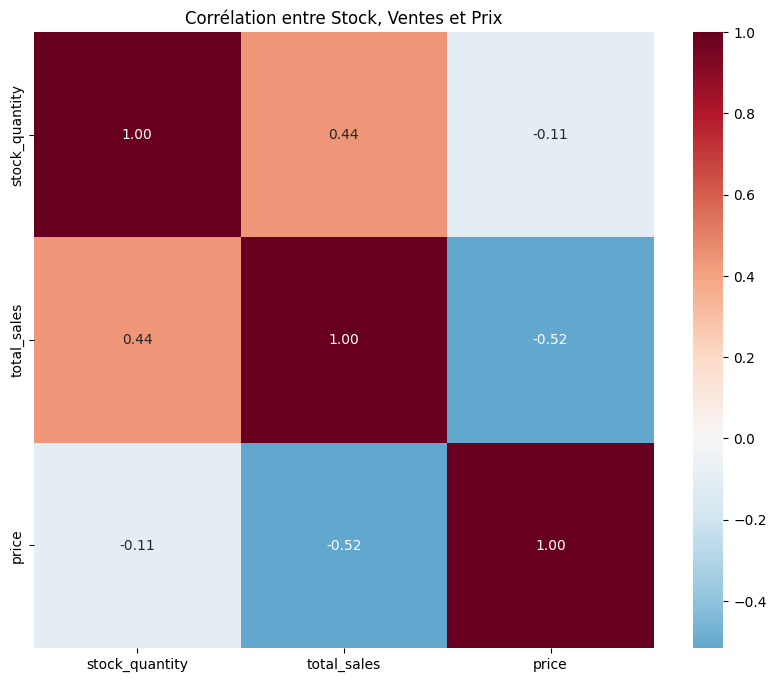

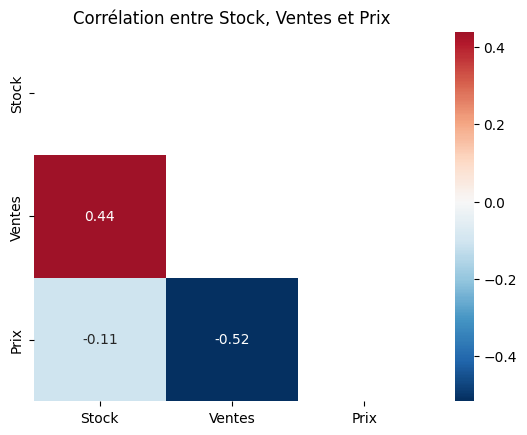

In [ ]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
#deja fais en debut de notebook 

#Création d'une heatmap de corrélation avec les variables stock, sales et price 
colonnes_corr = ['stock_quantity', 'total_sales', 'price']
corr_matrix = df_complet[colonnes_corr].corr()
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('Corrélation entre Stock, Ventes et Prix')
plt.show()

#On peut également créer un mask pour n'afficher qu'une demi heatmap
nouveaux_noms = ['Stock', 'Ventes', 'Prix']
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, xticklabels=nouveaux_noms, yticklabels=nouveaux_noms, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Corrélation entre Stock, Ventes et Prix')
plt.show()

In [ ]:
#Que peut-on conclure des corrélations ?
#une corelation Négative modére entre prix et les vente plus prix est haut moins les vente sont nombreuse (-0.52)
#pas de correlation entre les prix et les stocks (-0.11) Le prix n'est pas un facteur décisif pour décider du niveau de stock global.
#une correlation positive modéré entre vente et stock (0.44) la gestion logistique de Bottleneck est plutot bonne ils essaient d'avoir du stock là où il y a de la demande.


In [ ]:
#analyse complementaire avec un scatter plot entre vente et prix 

fig = px.scatter(df_complet, 
                 x='price', 
                 y='total_sales',
                 hover_name='post_title', 
                 trendline="ols",
                 trendline_color_override="red",
                 title='Relation entre le Prix et les Ventes Totales',
                 labels={'price': 'Prix de vente (€)', 'total_sales': 'Nombre de ventes'})

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
display(df_complet)
colonnes_sup_final = ["id_web", "post_name", "post_modified", "guid", "post_date"]
df_complet = df_complet.drop(columns=colonnes_sup_final)
df_complet.head()
df_complet.to_excel("analyse_bottleneck.xlsx", index=False)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type,z_score,ca_article,prix_HT,taux_marge
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,-0.294738,145.2,20.166667,56.573499
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,0.071253,308.7,28.583333,62.960851
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,-0.417943,0.0,17.333333,62.907268
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product,-0.660729,169.2,11.750000,69.797688
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product,0.495222,138.0,38.333333,61.267704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,1,8.4,28,instock,4.34,16135,16135,9.0,2.0,2020-04-25 13:22:38,2020-04-25 11:22:38,Vin,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,Belle robe jeune à dominante rubis soutenue. N...,mouthes-le-bihan-aime-chai-2015,2020-08-26 17:35:03,2020-08-26 15:35:03,https://www.bottle-neck.fr/?post_type=product&...,product,-0.867278,75.6,7.000000,61.290323
710,7023,1,27.5,23,instock,14.21,15891,15891,9.0,2.0,2020-05-02 14:53:40,2020-05-02 12:53:40,Vin,Camin Larredya Jurançon Sec La Virada 2018,L'exotisme du nez est complété par d'élégantes...,camin-larredya-jurancon-sec-la-virada-2018,2020-08-26 17:35:02,2020-08-26 15:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,-0.175157,247.5,22.916667,61.271405
711,7025,1,69.0,8,instock,34.22,15887,15887,5.0,2.0,2020-05-02 15:00:54,2020-05-02 13:00:54,Vin,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,"Pour cette cuvée, Jean-Paul Jamet recherche un...",jamet-cote-rotie-fructus-voluptas-2018,2020-08-14 18:15:03,2020-08-14 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,1.328666,345.0,57.500000,68.030392
712,7247,1,54.8,6,instock,27.18,13127-1,13127-1,4.0,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/?post_type=product&...,product,0.814105,219.2,45.666667,68.015698
